## Desafio 1 da Trilha de Visão Computacional

Nesse desafio você irá implementar uma solução simples para borrar o fundo de uma imagem como uma pessoa, semelhante ao que aplicativos de vídeo chamadas fazem hoje em dia.

Para isso você deverá seguir os pasos desse documento atentamente.

### Instalação e Importação da Biblioteca

In [4]:
!pip install opencv-python matplotlib

In [5]:
import cv2
import matplotlib.pyplot as plt

### Ler Imagens

In [ ]:
# Leia a imagem do arquivo "desafio_1.jpeg"
image_bgr = cv2.imread("desafio_1.jpeg")
# Converta a imagem de BGR para RGB para visualização.
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)

### Transformar em Escala de Cinza

In [ ]:
# Converte imagem para tons de cinza.
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")

### Detectar as Faces

Para isso iremos utilizar o `haar cascade` um método de detecção de faces clásscio. Mais detalhes sobre o `haar cascade` [aqui](https://docs.opencv.org/3.4/db/d28/tutorial_cascade_classifier.html)

In [ ]:
detec = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
face = detec.detectMultiScale(image_gray, 1.3, 3)
copy_image_rgb = image_rgb.copy()

padding = 20  # Defina quantos pixels de padding nas duas direções

for (x, y, larg, alt) in face: #Desenhar o retângulo
    ret = cv2.rectangle(copy_image_rgb, (x, y), (x + larg, y + alt), (0, 255, 0), 3)
    y, height = max(0, y-padding), min(y+alt+padding, image_rgb.shape[0])
    x, width = max(0, x-padding), min(x+larg+padding, image_rgb.shape[1])
    face_img = image_rgb[y:height,x:width,:]
plt.imshow(copy_image_rgb)

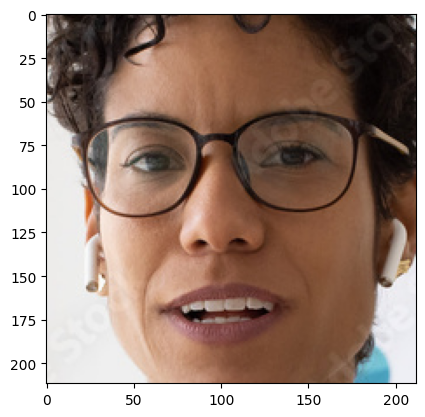

In [10]:
plt.imshow(face_img)

### Borrar a Imagem inteira

In [ ]:
# Borre a imagem inteira utilizando a função GaussianBlur.
blured_image = cv2.GaussianBlur(image_rgb, (51, 51), 0)
plt.imshow(blured_image)

### Substituir Imagem Original da Face na Imagem Borrada

In [ ]:
# Monte a imagem final com imagem borrada e na região da face coloce a imagem original.
final_image = blured_image.copy()  # Imagem borrada.
final_image[y:height, x:width, :] = face_img  # região da face recebe a imagem da face original.
plt.imshow(final_image)